# House Prices Modeling

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error

## 2. Data Loading

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
train_df.head(5)

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Exploratory Data Analysis

In [3]:
# Check basic info
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
# Check missing values
train_df.isnull().sum()[train_df.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

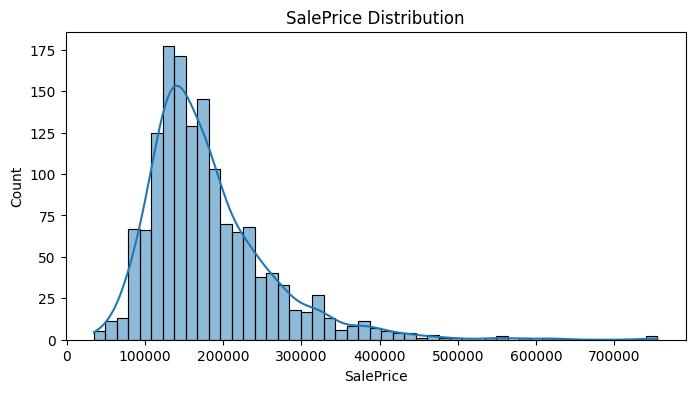

In [5]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
sns.histplot(train_df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

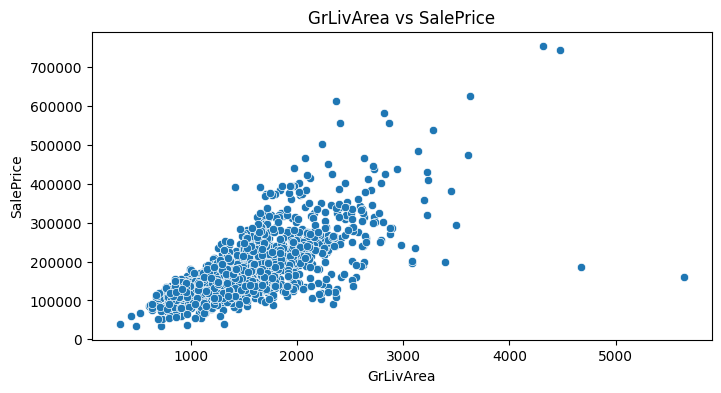

In [6]:
# Relationship between GrLivArea and SalePrice
plt.figure(figsize=(8, 4))
sns.scatterplot(x=train_df["GrLivArea"], y=train_df["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

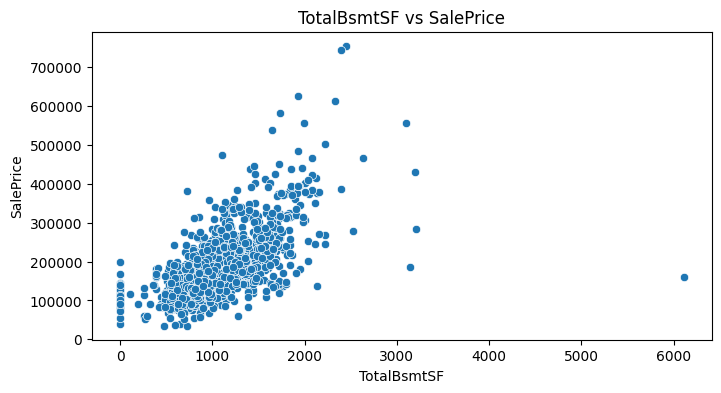

In [7]:
# Relationship between TotalBsmtSF and SalePrice
plt.figure(figsize=(8, 4))
sns.scatterplot(x=train_df["TotalBsmtSF"], y=train_df["SalePrice"])
plt.title("TotalBsmtSF vs SalePrice")
plt.xlabel("TotalBsmtSF")
plt.ylabel("SalePrice")
plt.show()

## 4. Feature Selection

In [8]:
# 2 continuous features
continuous_features = ["GrLivArea", "TotalBsmtSF"]

# 2 categorical features
categorical_features = ["Neighborhood", "BldgType"]

target = "SalePrice"

print("Continuous features:", continuous_features)
print("Categorical features:", categorical_features)

Continuous features: ['GrLivArea', 'TotalBsmtSF']
Categorical features: ['Neighborhood', 'BldgType']


In [9]:
# Check selected features
train_df[continuous_features + categorical_features].head(5)

,GrLivArea,TotalBsmtSF,Neighborhood,BldgType
0,1710,856,CollgCr,1Fam
1,1262,1262,Veenker,1Fam
2,1786,920,CollgCr,1Fam
3,1717,756,Crawfor,1Fam
4,2198,1145,NoRidge,1Fam


## 5. Train / Validation Split

In [10]:
X = train_df[continuous_features + categorical_features].copy()
y = train_df[target].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")

Train size: (1168, 4)
Validation size: (292, 4)


## 6. Feature Processing

In [11]:
# Handle missing values for continuous features
for col in continuous_features:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_val[col] = X_val[col].fillna(median_val)

# Handle missing values for categorical features
for col in categorical_features:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_val[col] = X_val[col].fillna(mode_val)

print("Missing values after handling:")
print(X_train.isnull().sum())

Missing values after handling:
GrLivArea       0
TotalBsmtSF     0
Neighborhood    0
BldgType        0
dtype: int64


In [12]:
# Scale continuous features
scaler = StandardScaler()
X_train_cont = scaler.fit_transform(X_train[continuous_features])
X_val_cont = scaler.transform(X_val[continuous_features])

print("Continuous features scaled successfully")
print("Shape:", X_train_cont.shape)

Continuous features scaled successfully
Shape: (1168, 2)


In [13]:
# Encode categorical features
encoders = {}
X_train_cat = np.zeros((len(X_train), len(categorical_features)))
X_val_cat = np.zeros((len(X_val), len(categorical_features)))

for i, col in enumerate(categorical_features):
    le = LabelEncoder()
    X_train_cat[:, i] = le.fit_transform(X_train[col])
    # Handle unseen labels in validation
    X_val[col] = X_val[col].apply(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
    X_val_cat[:, i] = le.transform(X_val[col])
    encoders[col] = le

print("Categorical features encoded successfully")
print("Shape:", X_train_cat.shape)

Categorical features encoded successfully
Shape: (1168, 2)


In [14]:
# Combine continuous and categorical features
X_train_processed = np.hstack([X_train_cont, X_train_cat])
X_val_processed = np.hstack([X_val_cont, X_val_cat])

print("Final processed train shape:", X_train_processed.shape)
print("Final processed val shape:", X_val_processed.shape)

Final processed train shape: (1168, 4)
Final processed val shape: (292, 4)


## 7. Model Training

In [15]:
model = LinearRegression()
model.fit(X_train_processed, y_train)
print("Model trained successfully!")

Model trained successfully!


## 8. Model Evaluation

In [16]:
def compute_rmsle(y_test: np.ndarray, y_pred: np.ndarray, precision: int = 2) -> float:
    """Note: y_pred values must be positive (log is applied)."""
    rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
    return round(rmsle, precision)

y_pred = model.predict(X_val_processed)

# Clip negative predictions to avoid log errors
y_pred = np.clip(y_pred, 1, None)

rmsle = compute_rmsle(y_val.values, y_pred)
print(f"Validation RMSLE: {rmsle}")

Validation RMSLE: 0.25
